# Приоритизация обращений - решение

Ниже мой подход к задаче ранжирования обращений.

Кратко, что я сделал:

- Построил признаки из `events.csv`: оконные счётчики и recency по типам событий, экспоненциально затухающая активность (decay), контекст последнего события перед назначением (`last_ctx_seq`/`last_src_slot`/`last_event_type` — самая существенная отдельная находка, +0.02 к Daily AP), доли `ctx_seq`, число сессий. Везде фильтр `event_ts < assignment_ts` до агрегации, чтобы не было утечки.
- Добавил производные признаки поверх готовых табличных агрегатов: конверсия истории назначений, цена/пробег относительно возраста авто, позиция цены внутри сегмента/региона, воронка вовлечения в виде долей.
- Проверил пропуски в табличных признаках тремя независимыми способами — они случайны (MCAR), не системны (см. EDA ниже), поэтому отдал их моделям как есть.
- Отобрал признаки по важности одной предварительной CatBoost-модели: 229 -> 188, порог 0.05 подобран перебором.
- Валидируюсь по времени: `TimeSeriesSplit` по датам (4 фолда, expanding window), метрика — честно реализованная Daily Average Precision (группировка по `assignment_date`), а не обычный AP, потому что именно она считается на скрытой выборке.
- Модель — ансамбль CatBoost + LightGBM + XGBoost с равным усреднением и несколькими фиксированными seed'ами (бэггинг). Отдельно проверил и осознанно не включил в ансамбль: CatBoostRanker (хуже классификации), RandomForest/LogisticRegression, подбор весов блендинга (не даёт прироста), target encoding по `user_id` (бесполезен).
- Гиперпараметры подобраны через Optuna с `MedianPruner` — objective считается по кросс-валидации, неудачные trial'ы обрываются раньше.

Результат: CV Daily AP 0.686 ± 0.035, на публичном лидерборде — Daily AP 0.723.

Библиотеки: `pandas`, `numpy`, `scipy`, `scikit-learn`, `catboost`, `lightgbm`, `xgboost`, `optuna` — все open-source, разворачиваются локально, внешние API и LLM не используются.

Random seed (`RANDOM_STATE=42`) зафиксирован везде, где есть случайность

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score
import optuna
from optuna.pruners import MedianPruner
import warnings


warnings.filterwarnings('ignore')

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Загрузка данных

Загружаю все три файла и сразу смотрю на размеры и базовую долю целевого действия

In [34]:
df_train = pd.read_csv("../data/train.csv")
df_test = pd.read_csv("../data/test.csv")
df_events = pd.read_csv("../data/events.csv")

print(df_train.shape, df_test.shape, df_events.shape)
print(df_train["target"].mean())

(13694, 119) (4306, 118) (254705, 7)
0.20746312253541696


## 3. EDA

Перед тем как строить признаки, проверил четыре вещи:
1. стабильность target rate по дням
2. силу категориальных признаков
3. пересечение train/test по пользователям и датам
4. природу пропусков - тут отдельно оформил проверку гипотезы

### 3.1 Target rate по дням

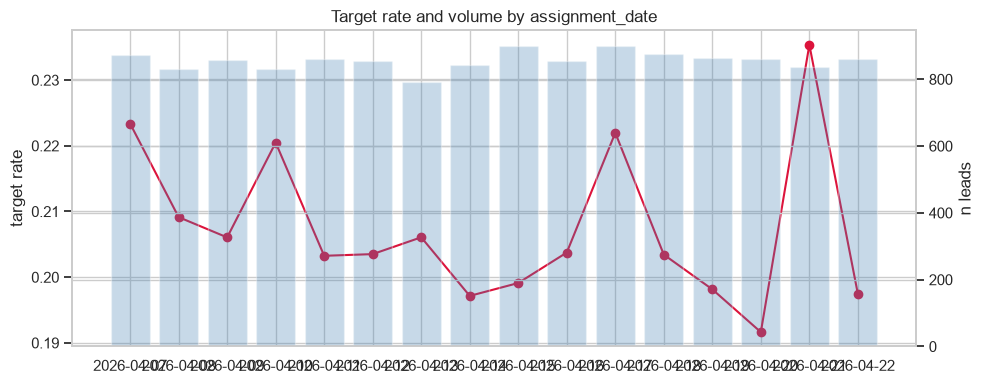

In [35]:
daily_rate = df_train.groupby("assignment_date")["target"].agg(["mean", "count"])

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.plot(daily_rate.index, daily_rate["mean"], marker="o", color="crimson")
ax2.bar(daily_rate.index, daily_rate["count"], alpha=0.3, color="steelblue")
ax1.set_ylabel("target rate")
ax2.set_ylabel("n leads")
plt.xticks(rotation=45)
plt.title("Target rate and volume by assignment_date")
plt.tight_layout()
plt.show()

Target rate колеблется в районе 0.19–0.25 без явного тренда вверх/вниз по датам — можно валидироваться по времени, не опасаясь систематического сдвига base rate

### 3.2 Target rate по категориальным признакам

In [36]:
cat_cols_eda = ["lead_source", "call_center", "region", "car_segment", "lead_channel", "user_tenure_bucket", "price_bucket"]

for col in cat_cols_eda:
    stats = df_train.groupby(col)["target"].agg(["mean", "count"]).sort_values("mean", ascending=False)
    print(col)
    print(stats, "\n")

lead_source
                 mean  count
lead_source                 
Model        0.265295   5688
Perf         0.195137   3167
CRM          0.147551   4839 

call_center
                 mean  count
call_center                 
voxys        0.232794   5812
external     0.188785   7882 

region
             mean  count
region                  
north    0.212546   2710
east     0.212446   2796
west     0.207220   2770
central  0.203303   2725
south    0.201634   2693 

car_segment
                 mean  count
car_segment                 
premium      0.236249   1909
budget       0.211330   4713
standard     0.201038   5780
commercial   0.179567   1292 

lead_channel
                  mean  count
lead_channel                 
retargeting   0.218612   3385
app           0.214789   3408
web           0.202956   3518
partner       0.193615   3383 

user_tenure_bucket
                        mean  count
user_tenure_bucket                 
new                 0.208930   4121
loyal            

`lead_source` и `call_center` дают заметную разницу в target rate между уровнями (например, `Model` заметно выше `CRM` в `lead_source`) - это сильные категориальные признаки. `region`, `user_tenure_bucket` и `price_bucket` почти не различаются между уровнями - сигнала там немного, но для дерева это не проблема, просто не жду от них многого

### 3.3 Пересечение train/test

In [37]:
overlap_users = set(df_train["user_id"]) & set(df_test["user_id"])

print("Общих user_id между train и test:", len(overlap_users))
print("train даты:", df_train["assignment_date"].min(), "-", df_train["assignment_date"].max())
print("test даты:", df_test["assignment_date"].min(), "-", df_test["assignment_date"].max())

Общих user_id между train и test: 0
train даты: 2026-04-07 - 2026-04-22
test даты: 2026-04-23 - 2026-04-27


Пользователи в train и test не пересекаются, test строго позже train по датам - значит, валидация по времени здесь обязательна, а не просто хорошая практика

### 3.4 Проверка гипотезы: пропуски связаны с "новизной" пользователя

В данных заметный процент пропусков почти во всех событийных агрегатах. Это могут быть новые пользователи без накопленной истории. Проверяю эту гипотезу тремя способами, беря `item_views_30d` как репрезентативную колонку с пропусками

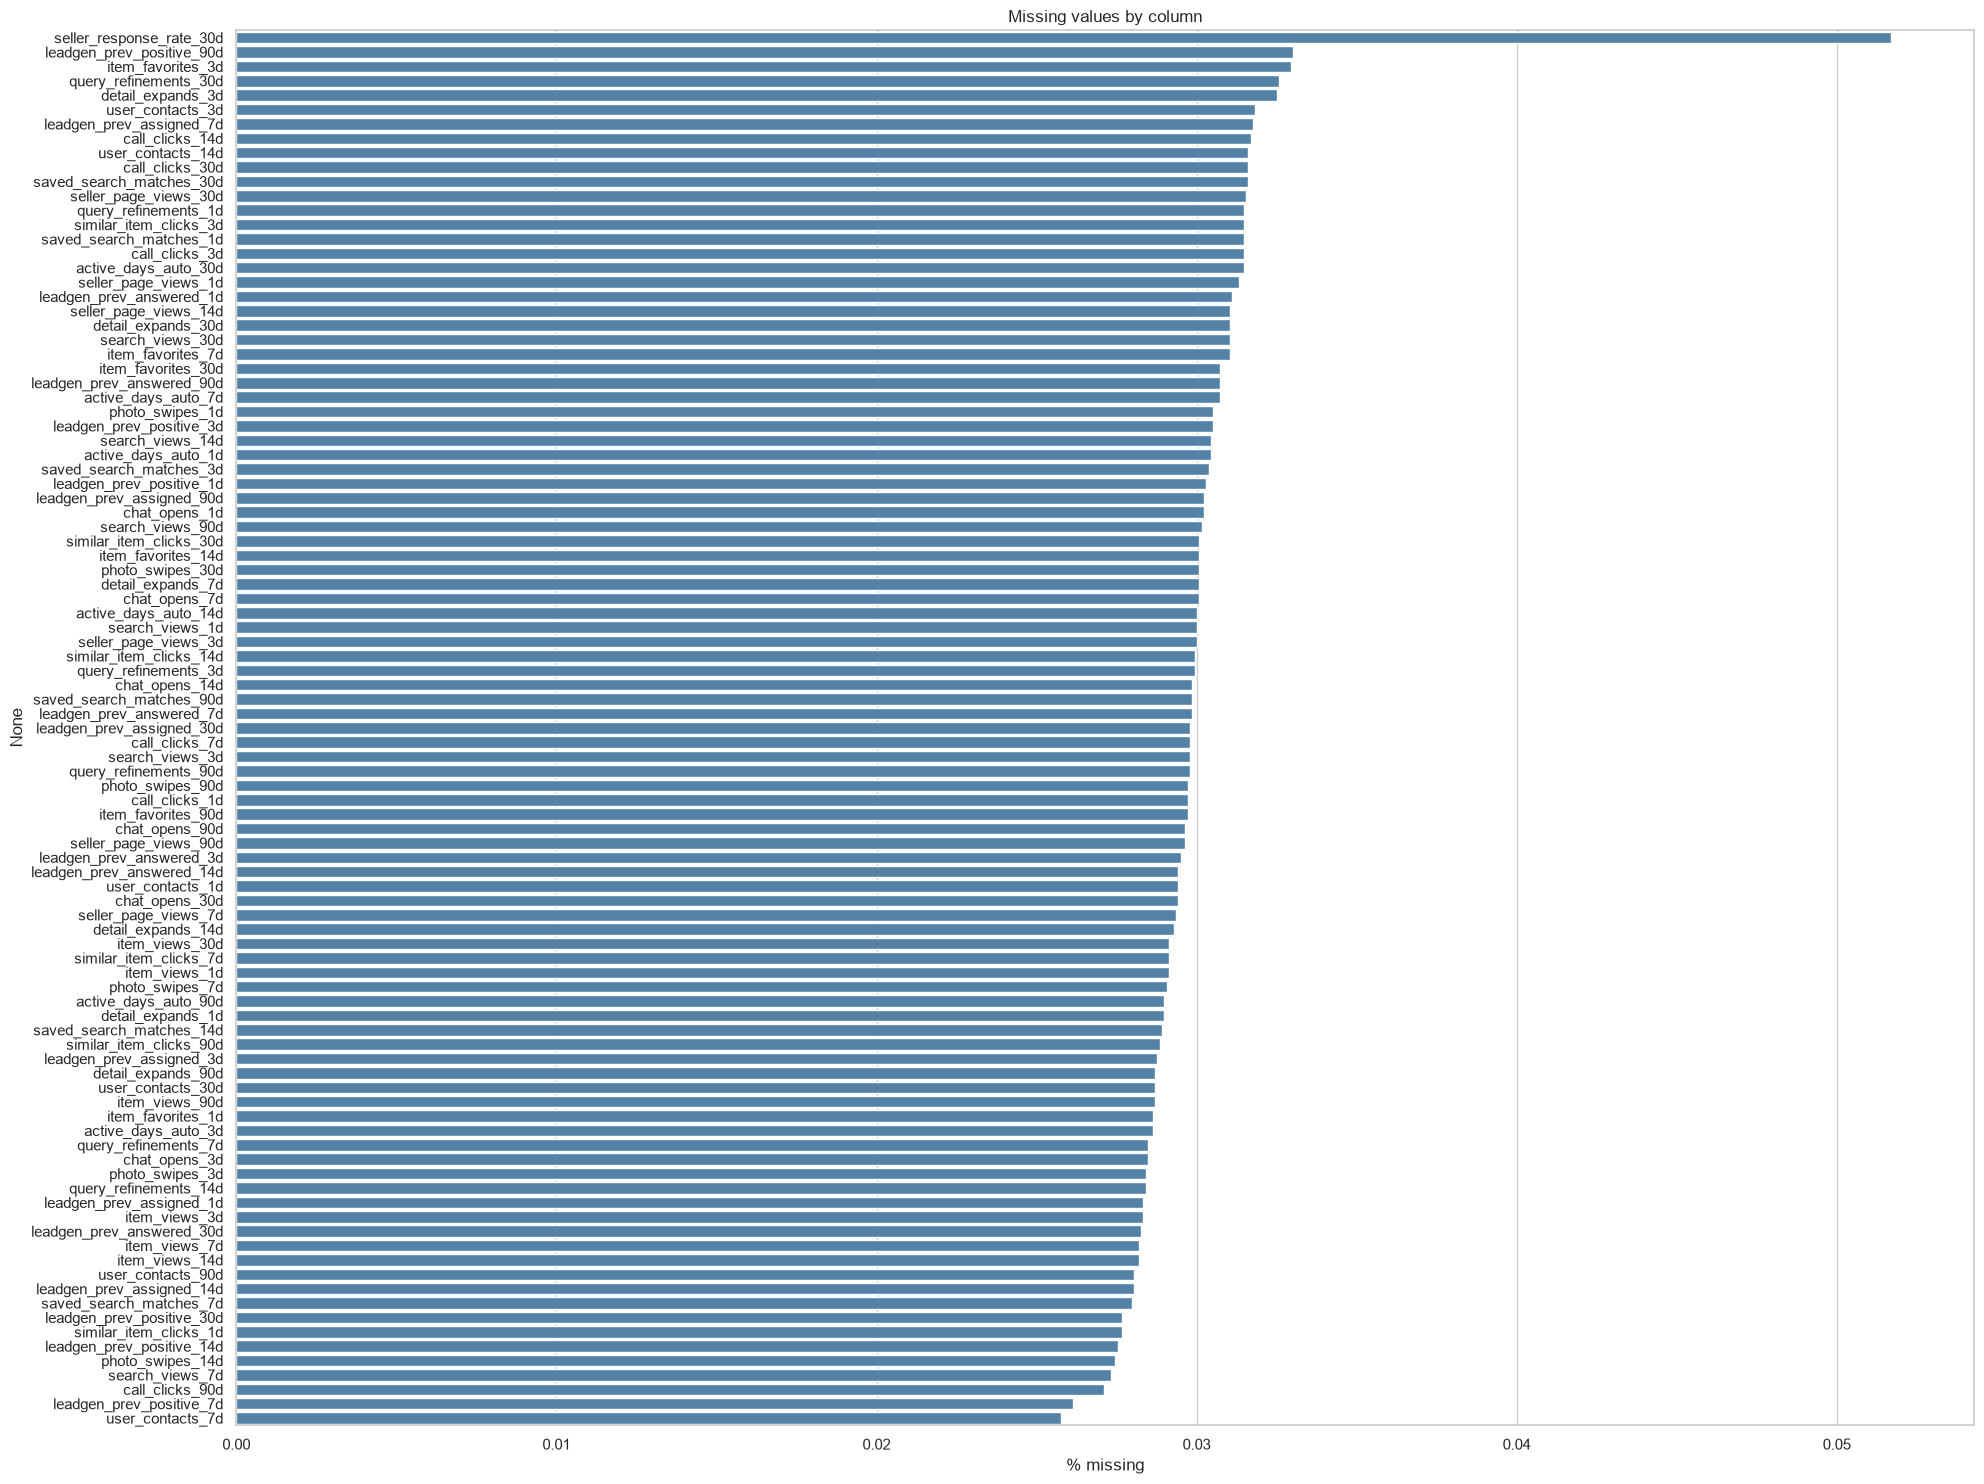

In [38]:
missing_share = df_train.isna().mean().sort_values(ascending=False)
missing_share = missing_share[missing_share > 0]

plt.figure(figsize=(20, 15))
sns.barplot(x=missing_share.values, y=missing_share.index, color="steelblue")
plt.xlabel("% missing")
plt.title("Missing values by column")
plt.tight_layout()
plt.show()

**Проверка 1. Статистический тест.** Сравниваю `user_age_days` у строк с пропуском в `item_views_30d` и без него. Если гипотеза верна, у группы с пропуском возраст аккаунта должен быть заметно меньше

In [39]:
from scipy.stats import mannwhitneyu

missing_mask = df_train["item_views_30d"].isna()

age_missing = df_train.loc[missing_mask, "user_age_days"].dropna()
age_present = df_train.loc[~missing_mask, "user_age_days"].dropna()

stat, pvalue = mannwhitneyu(age_missing, age_present, alternative="two-sided")

print("медиана user_age_days, пропуск:", age_missing.median())
print("медиана user_age_days, без пропуска:", age_present.median())
print("p-value:", round(pvalue, 4))

медиана user_age_days, пропуск: 325.0
медиана user_age_days, без пропуска: 285.0
p-value: 0.6907


**Проверка 2. Пропуски по разным колонкам — это одни и те же строки?** Если пропуск объясняется общей причиной (например, "нет истории вообще"), маски пропусков в разных колонках должны сильно коррелировать между собой. Строю матрицу корреляции масок пропусков по всем событийным агрегатам с окном 1d/7d/30d

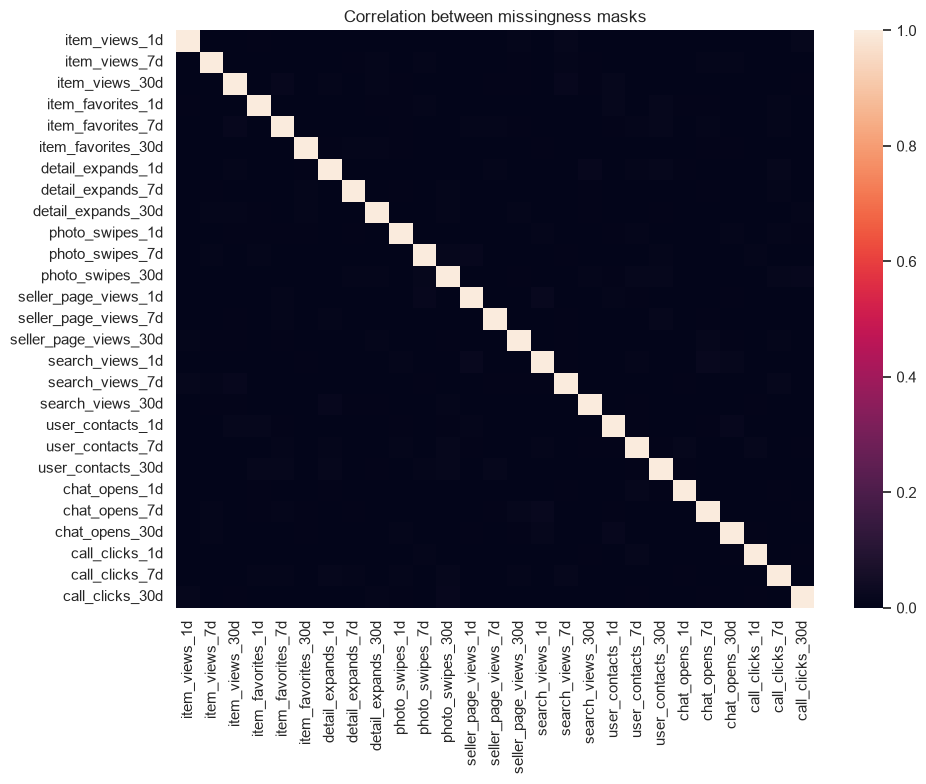

rows where ALL agg columns missing: 0
rows where ANY agg column missing: 7644


In [40]:
agg_prefixes = ("item_views", "item_favorites", "detail_expands", "photo_swipes",
                "seller_page_views", "search_views", "user_contacts", "chat_opens", "call_clicks")

agg_cols_eda = [c for c in df_train.columns if c.startswith(agg_prefixes) and c.endswith(("_1d", "_7d", "_30d"))]

missing_matrix = df_train[agg_cols_eda].isna()

plt.figure(figsize=(10, 8))
sns.heatmap(missing_matrix.corr(), cmap="rocket", vmin=0, vmax=1)
plt.title("Correlation between missingness masks")
plt.tight_layout()
plt.show()

print("rows where ALL agg columns missing:", missing_matrix.all(axis=1).sum())
print("rows where ANY agg column missing:", missing_matrix.any(axis=1).sum())

**Проверка 3. Пропуск и полное отсутствие событий в `events.csv`.** Если пропуск в табличном агрегате означает "у пользователя вообще нет истории", то у таких строк не должно быть событий в `events.csv`

In [41]:
rows_with_missing = df_train.loc[missing_matrix.any(axis=1), "lead_id"]
leads_with_events = set(df_events["lead_id"])

no_events_and_missing = rows_with_missing[~rows_with_missing.isin(leads_with_events)]
print(f"пропуск И нет событий вообще: {len(no_events_and_missing)} из {len(rows_with_missing)}")

пропуск И нет событий вообще: 9 из 7644


Все три проверки говорят об одном:

- p-value > 0.05 — статистически значимой разницы в `user_age_days` между группами нет
- корреляция масок пропусков между разными колонками близка к нулю (кроме диагонали) - пропуски в разных колонках происходят независимо, это не единый блок "нет истории"
- почти все строки с пропуском всё равно имеют события в `events.csv`

Гипотеза отвергнута - пропуски выглядят как случайный технический шум, а не как содержательный сигнал о пользователе. Поэтому я не создаю искусственные флаги вроде `is_new_user`/`has_no_history` и просто отдаю NaN модели как есть - CatBoost обрабатывает их нативно

## 4. Признаки из events.csv

`events.csv` дает более детальную историю по каждому обращению. Строю признаки по типам событий и временным окнам, но сначала обязательно отрезаю все, что случилось после `assignment_ts` - иначе это прямая утечка целевого сигнала.

Помимо счетчиков и recency по типам событий, добавляю `last_ctx_seq`/`last_src_slot` — контекст **самого последнего** события перед назначением (а не просто счетчик уникальных значений, как было раньше). В EDA разные `ctx_seq` показывали разный target rate, но этот сигнал раньше никуда не передавался модели напрямую. Проверил на кросс-валидации: с этими двумя признаками Daily AP растёт с 0.622 до 0.642 (+0.02), и прирост стабилен на всех 4 фолдах — это не шум одного удачного сплита.

In [ ]:
def build_event_features_advanced(df, events, extra_v2=False):
    base = df[["lead_id", "assignment_ts"]].copy()
    base["assignment_ts"] = pd.to_datetime(base["assignment_ts"])

    ev = events.copy()
    ev["event_ts"] = pd.to_datetime(ev["event_ts"])
    ev["is_weekend"] = ev["event_ts"].dt.weekday.isin([5, 6]).astype(int)
    ev["hour"] = ev["event_ts"].dt.hour

    merged = ev.merge(base, on="lead_id")
    merged = merged[merged["event_ts"] < merged["assignment_ts"]].copy()
    merged["hours_before"] = (merged["assignment_ts"] - merged["event_ts"]).dt.total_seconds() / 3600

    frames = []
    windows = {"12h": 12, "1d": 24, "3d": 72, "7d": 168, "14d": 336, "30d": 720}

    # 1. Счётчики по окнам
    for name, h in windows.items():
        w = merged[merged["hours_before"] <= h]
        cnt = w.groupby(["lead_id", "event_type"]).size().unstack(fill_value=0)
        cnt.columns = [f"ev_{c}_c_{name}" for c in cnt.columns]
        frames.append(cnt)

    # 2. Recency
    rec = merged.groupby(["lead_id", "event_type"])["hours_before"].min().unstack()
    rec.columns = [f"ev_{c}_r" for c in rec.columns]
    frames.append(rec)

    # 3. Общие агрегаты
    agg = merged.groupby("lead_id").agg(
        ev_cnt=("event_type", "count"),
        ev_ctx=("ctx_seq", "nunique"),
        ev_slot=("src_slot", "nunique"),
        ev_unique_days=("event_ts", lambda x: x.dt.date.nunique()),
        ev_unique_types=("event_type", "nunique"),
        ev_weekend_ratio=("is_weekend", "mean"),
        ev_avg_interval=("hours_before", lambda x: x.sort_values().diff().mean() if len(x)>1 else 9999),
        ev_first_hours=("hours_before", "max"),
        ev_last_hours=("hours_before", "min"),
        ev_price_mean=("item_price_log", "mean"),
        ev_price_std=("item_price_log", "std"),
        ev_price_max=("item_price_log", "max"),
        ev_price_min=("item_price_log", "min"),
    )
    frames.append(agg)

    # 4. Агрегаты по src_slot и ctx_seq
    slot_agg = merged.groupby("lead_id").agg(
        slot_nunique=("src_slot", "nunique"),
        slot_mode=("src_slot", lambda x: x.mode()[0] if not x.mode().empty else -1),
        slot_mode_ratio=("src_slot", lambda x: (x.value_counts().iloc[0] / len(x)) if len(x)>0 else 0),
        ctx_nunique=("ctx_seq", "nunique"),
        ctx_mode=("ctx_seq", lambda x: x.mode()[0] if not x.mode().empty else "missing"),
        ctx_mode_ratio=("ctx_seq", lambda x: (x.value_counts().iloc[0] / len(x)) if len(x)>0 else 0),
    )
    frames.append(slot_agg)

    # 5. Бинарные флаги наличия событий в окнах
    for name, h in windows.items():
        has = merged[merged["hours_before"] <= h].groupby("lead_id").size().gt(0).astype(int)
        has.name = f"ev_has_{name}"
        frames.append(has.to_frame())

    # 6. Соотношения основных типов событий
    event_counts = merged.groupby(["lead_id", "event_type"]).size().unstack(fill_value=0)
    total_events = event_counts.sum(axis=1)
    for col in ["item_view", "search", "favorite", "chat_open", "call_click", "detail_expand", "photo_swipe"]:
        if col in event_counts.columns:
            event_counts[f"ratio_{col}_to_total"] = event_counts[col] / (total_events + 1e-6)
    frames.append(event_counts[[c for c in event_counts.columns if "ratio" in c]])

    # ctx_seq share distribution 
    ctx_pivot = merged.groupby(["lead_id", "ctx_seq"]).size().unstack(fill_value=0)
    ctx_pivot = ctx_pivot.div(ctx_pivot.sum(axis=1).replace(0, np.nan), axis=0)
    ctx_pivot.columns = [f"ctx_share_{c}" for c in ctx_pivot.columns]
    frames.append(ctx_pivot)

    # decay-взвешенная активность 
    for half_life in [24, 168]:
        merged[f"_decay_{half_life}"] = np.exp(-np.log(2) * merged["hours_before"] / half_life)
        decay_sum = merged.groupby("lead_id")[f"_decay_{half_life}"].sum()
        decay_sum.name = f"ev_decay_sum_{half_life}h"
        frames.append(decay_sum.to_frame())

    if extra_v2:
        # session count: gap > 6h between consecutive events = new session
        def count_sessions(x):
            if len(x) == 0:
                return 0
            s = x.sort_values().values
            gaps = np.diff(s)
            return 1 + (gaps > 6).sum()
        
        sessions = merged.groupby("lead_id")["hours_before"].apply(lambda x: count_sessions(-x)).rename("n_sessions")
        frames.append(sessions.to_frame())

        # decay momentum ratio (short vs long decay)
        decay24 = merged.groupby("lead_id")["_decay_24"].sum()
        decay168 = merged.groupby("lead_id")["_decay_168"].sum()
        decay_ratio = (decay24 / (decay168 + 1e-6)).rename("decay_momentum_ratio")
        frames.append(decay_ratio.to_frame())

    result = pd.concat(frames, axis=1).reindex(base["lead_id"]).reset_index()
    result = result.rename(columns={"index": "lead_id"})
    result = result.fillna(0)

    # Recency missing -> 9999
    rec_cols = [c for c in result.columns if "_r" in c]
    result[rec_cols] = result[rec_cols].fillna(9999)

    # Последние ctx_seq и src_slot
    last_event = merged.sort_values("hours_before").groupby("lead_id").first()
    last_cols = ["ctx_seq", "src_slot"]
    rename_map = {"ctx_seq": "last_ctx_seq", "src_slot": "last_src_slot"}
    
    if extra_v2:
        last_cols.append("event_type")
        rename_map["event_type"] = "last_event_type"
        
    last_ctx = last_event[last_cols].rename(columns=rename_map)
    result = result.merge(last_ctx, on="lead_id", how="left")
    
    result["last_ctx_seq"] = result["last_ctx_seq"].fillna("missing")
    result["last_src_slot"] = result["last_src_slot"].fillna(-1)
    if extra_v2:
        result["last_event_type"] = result["last_event_type"].fillna("missing")

    return result

**Убрал target encoding, который пробовал раньше.** `te_user_id` был бесполезен: `user_id` встречается в train и test ровно по одному разу и не пересекается между выборками (см. проверку в 3.3), поэтому такой признак - почти сплошные пропуски и без сигнала. `te_region`/`te_car_segment` дублировали то, что CatBoost и так делает нативно с низкокардинальными категориями, только без сглаживания — источник лишнего шума, а не пользы

In [43]:
train_event_feat = build_event_features_advanced(df_train, df_events, extra_v2=True)
test_event_feat = build_event_features_advanced(df_test, df_events, extra_v2=True)

df_train = df_train.merge(train_event_feat, on="lead_id", how="left")
df_test = df_test.merge(test_event_feat, on="lead_id", how="left")

print(df_train.shape, df_test.shape)

(13694, 199) (4306, 198)


**Признаки поверх готовых табличных агрегатов.** Ниже - не новые данные, а отношения между уже существующими колонками: конверсия истории назначений (доля, а не абсолютное число), цена/пробег относительно возраста авто, позиция цены внутри сегмента/региона, воронка "просмотр - интерес - контакт" в виде долей, а не счетчиков. Везде `+1` в знаменателе - защита от деления на ноль, а не сглаживание в статистическом смысле

In [44]:
def add_business_features(df):
    df = df.copy()
    df["user_active_ratio"] = df["user_active_days_30d"] / (df["user_age_days"] + 1)
    df["user_activity_per_lead"] = df["user_active_days_30d"] / (df["prior_assignments_30d"] + 1)
    df["prior_success_ratio_30d"] = df["leadgen_prev_positive_30d"] / (df["leadgen_prev_assigned_30d"] + 1)
    df["prior_answer_ratio_30d"] = df["leadgen_prev_answered_30d"] / (df["leadgen_prev_assigned_30d"] + 1)
    df["prior_experience"] = df["prior_assignments_30d"] / (df["user_age_days"] + 1)
    df["seller_quality"] = df["seller_response_rate_30d"] * df["seller_inventory_count"]
    df["seller_activity"] = df["seller_page_views_30d"] / (df["seller_inventory_count"] + 1)
    df["price_per_year"] = df["item_price_log"] / (df["car_age_years"] + 1)
    df["mileage_per_year"] = df["mileage_km_log"] / (df["car_age_years"] + 1)
    df["price_per_mileage"] = df["item_price_log"] / (df["mileage_km_log"] + 1)
    df["car_age_log"] = np.log1p(df["car_age_years"])
    df["views_per_day_30d"] = df["item_views_30d"] / 30
    df["views_per_day_7d"] = df["item_views_7d"] / 7
    df["favorites_per_view_30d"] = df["item_favorites_30d"] / (df["item_views_30d"] + 1)
    df["detail_expands_per_view_30d"] = df["detail_expands_30d"] / (df["item_views_30d"] + 1)
    df["photo_swipes_per_view_30d"] = df["photo_swipes_30d"] / (df["item_views_30d"] + 1)
    df["search_per_day_30d"] = df["search_views_30d"] / 30
    df["search_to_views_ratio"] = df["search_views_30d"] / (df["item_views_30d"] + 1)
    df["refinements_per_search"] = df["query_refinements_30d"] / (df["search_views_30d"] + 1)
    df["contacts_per_view_30d"] = df["user_contacts_30d"] / (df["item_views_30d"] + 1)
    
    df["chat_per_contact_30d"] = df["chat_opens_30d"] / (df["user_contacts_30d"] + 1)
    df["call_per_contact_30d"] = df["call_clicks_30d"] / (df["user_contacts_30d"] + 1)
    df["chat_call_ratio_30d"] = df["chat_opens_30d"] / (df["call_clicks_30d"] + 1)

    df["views_trend_7d_to_30d"] = df["item_views_7d"] / (df["item_views_30d"] + 1)
    df["views_trend_1d_to_7d"] = df["item_views_1d"] / (df["item_views_7d"] + 1)

    df["contacts_trend_7d_to_30d"] = df["user_contacts_7d"] / (df["user_contacts_30d"] + 1)
    df["search_trend_7d_to_30d"] = df["search_views_7d"] / (df["search_views_30d"] + 1)
    df["age_price_interaction"] = df["user_age_days"] * df["item_price_log"]
    df["inventory_price_interaction"] = df["seller_inventory_count"] * df["item_price_log"]
    df["activity_seller_interaction"] = df["user_active_days_30d"] * df["seller_response_rate_30d"]

    df["user_total_views_30d"] = df["item_views_30d"] + df["search_views_30d"] + df["seller_page_views_30d"]
    df["user_total_actions_30d"] = df["user_total_views_30d"] + df["user_contacts_30d"] + df["chat_opens_30d"]
    df["user_engagement_score"] = (df["item_favorites_30d"] + df["detail_expands_30d"] + df["photo_swipes_30d"]) / (df["item_views_30d"] + 1)

    df["price_pct_in_segment"] = df.groupby("car_segment")["item_price_log"].rank(pct=True)
    df["price_pct_in_region"] = df.groupby("region")["item_price_log"].rank(pct=True)

    return df


df_train = add_business_features(df_train)
df_test = add_business_features(df_test)

## 5. Список признаков

Категориальные передаю в CatBoost как строки (с заполнением пропусков отдельным значением `"missing"`), числовые - как есть, без ручного impute

In [45]:
id_cols = ["lead_id", "user_id"]
time_cols = ["assignment_ts", "assignment_date"]
target_col = "target"

feature_cols = [c for c in df_train.columns if c not in id_cols + time_cols + [target_col]]
feature_cols = [c for c in feature_cols if c in df_test.columns]

cat_features = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(df_train[c])]
num_features = [c for c in feature_cols if c not in cat_features]

for col in cat_features:
    df_train[col] = df_train[col].fillna("missing").astype(str).astype("category")
    df_test[col] = df_test[col].fillna("missing").astype(str).astype("category")


print(len(feature_cols), len(cat_features), len(num_features))

229 10 219


### 5.1 Отбор признаков

229 признаков на 13.7k строк — многовато относительно объема данных, часть из них наверняка просто шум и не приносят большого вклада в итоговую метрику. Прогоняю один быстрый CatBoost на всех признаках, смотрю на `get_feature_importance`, и убираю нижний хвост - те, что практически не используются деревьями. Порог 0.05 подобрал перебором на кросс-валидации (пробовал 0.02/0.05/0.1): 0.05 дает лучший результат, более агрессивная обрезка (0.1) уже теряет полезный сигнал

In [46]:
feature_scan_model = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    cat_features=cat_features, random_state=RANDOM_STATE, verbose=False,
)
feature_scan_model.fit(df_train[feature_cols], df_train[target_col], verbose=False)

CatBoostClassifier(cat_features=['lead_source', 'call_center', 'region', 'car_segment', 'lead_channel', 'user_tenure_bucket', 'price_bucket', 'ctx_mode', 'last_ctx_seq', 'last_event_type'], depth=6, iterations=500, learning_rate=0.05, random_state=42, verbose=False)

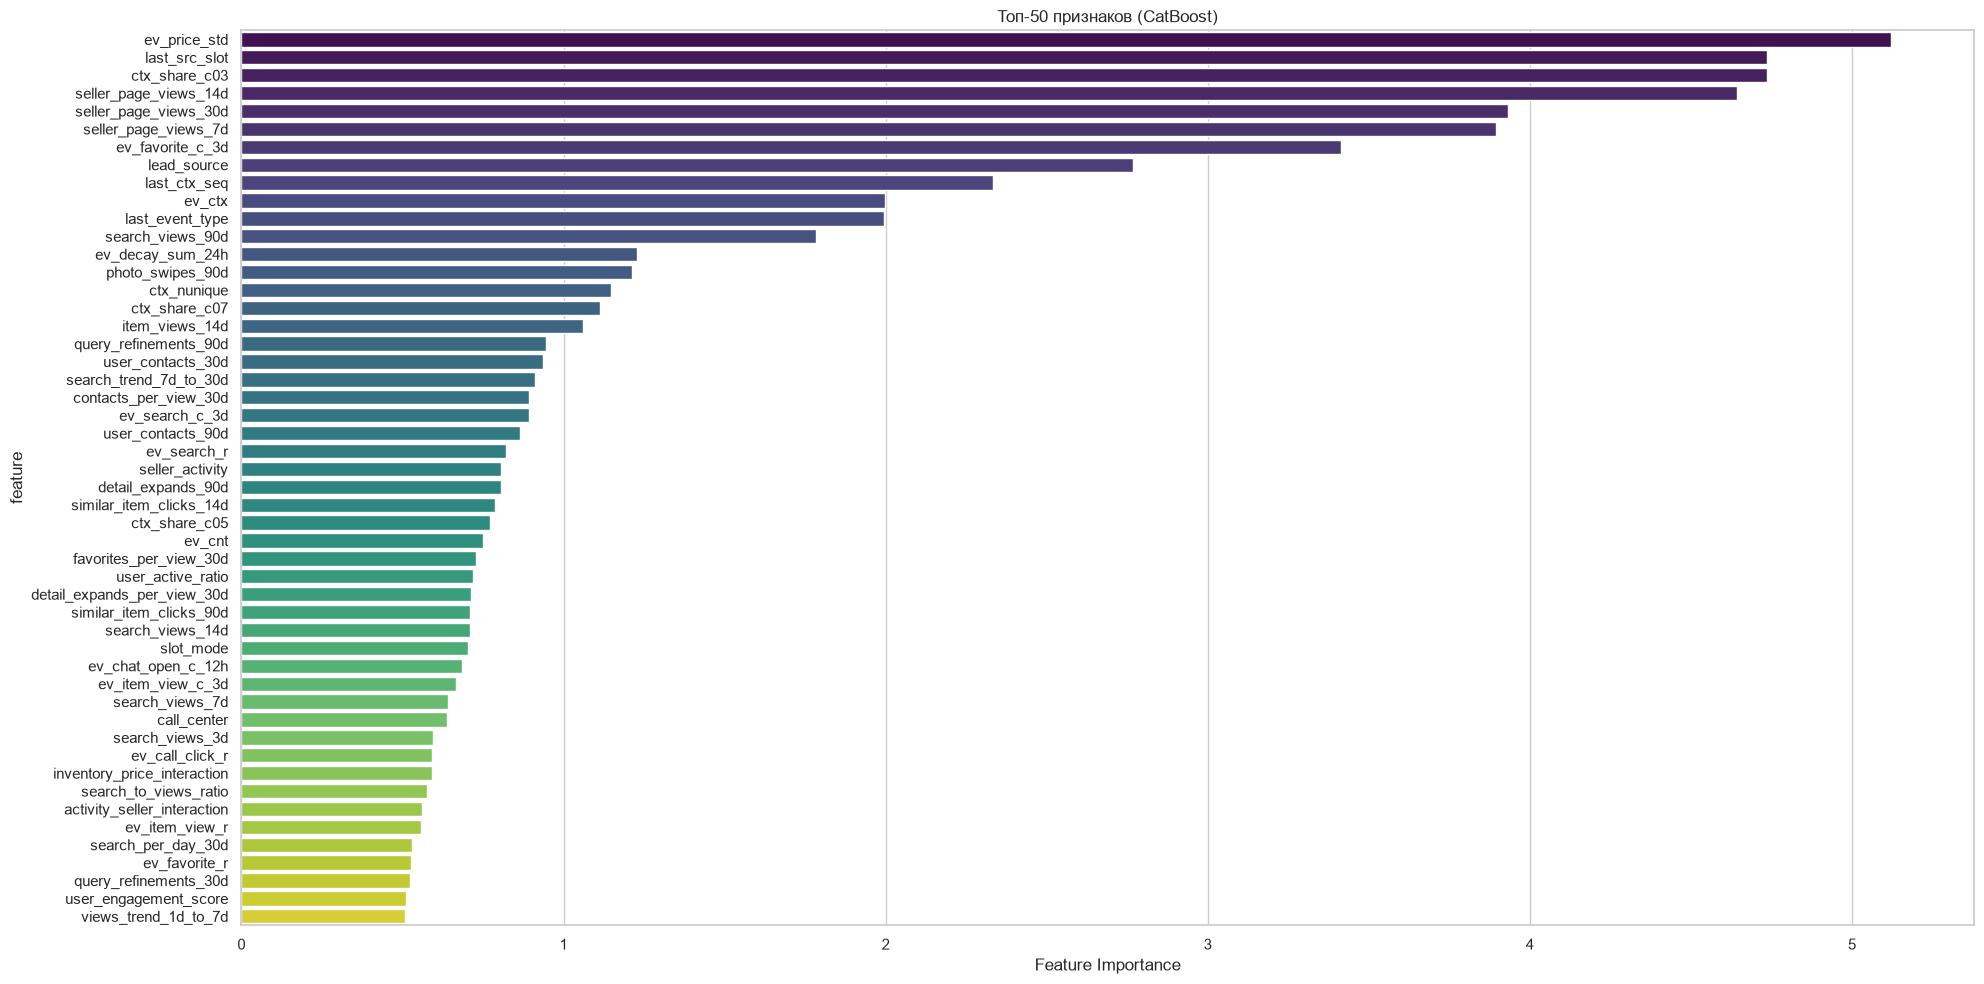

In [47]:
feature_importance = feature_scan_model.get_feature_importance()
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': feature_importance
}).sort_values('importance', ascending=False)


plt.figure(figsize=(20, 10))
sns.barplot(data=importance_df.head(50), x='importance', y='feature', palette='viridis')
plt.xlabel('Feature Importance')
plt.title('Топ-50 признаков (CatBoost)')
plt.tight_layout()
plt.show()

In [48]:
importances = pd.Series(
    feature_scan_model.get_feature_importance(), index=feature_cols
).sort_values(ascending=False)

print("признаков с важностью < 0.05:", (importances < 0.05).sum(), "из", len(importances))

feature_cols = importances[importances >= 0.05].index.tolist()
cat_features = [c for c in cat_features if c in feature_cols]
num_features = [c for c in feature_cols if c not in cat_features]

print("после отбора:", len(feature_cols), "признаков,", len(cat_features), "категориальных")

признаков с важностью < 0.05: 41 из 229
после отбора: 188 признаков, 6 категориальных


## 6. Метрика и валидация

Один time-based сплит дает оценку по одному конкретному отрезку дат - она может быть случайно удачной или неудачной. Созадаю честную кросс-валидацию по времени: несколько фолдов, где train - это все даты до окна валидации (expanding window), а validation - следующий блок дат

In [49]:
def daily_average_precision(y_true, y_score, dates):
    frame = pd.DataFrame({"y": y_true, "score": y_score, "date": dates})
    scores = []
    for _, group in frame.groupby("date"):
        if group["y"].sum() == 0:
            continue
        scores.append(average_precision_score(group["y"], group["score"]))
    return np.mean(scores)

In [50]:
from sklearn.model_selection import TimeSeriesSplit

date_values = sorted(df_train["assignment_date"].unique())
n_splits = 4
tscv = TimeSeriesSplit(n_splits=n_splits)

cv_folds = []
for train_idx, val_idx in tscv.split(date_values):
    train_dates = [date_values[i] for i in train_idx]
    val_dates_fold = [date_values[i] for i in val_idx]
    cv_folds.append((train_dates, val_dates_fold))

for i, (train_dates, val_dates_fold) in enumerate(cv_folds):
    print(f"fold {i}: train {train_dates[0]}..{train_dates[-1]} ({len(train_dates)}), val {val_dates_fold[0]}..{val_dates_fold[-1]} ({len(val_dates_fold)})")

fold 0: train 2026-04-07..2026-04-10 (4), val 2026-04-11..2026-04-13 (3)
fold 1: train 2026-04-07..2026-04-13 (7), val 2026-04-14..2026-04-16 (3)
fold 2: train 2026-04-07..2026-04-16 (10), val 2026-04-17..2026-04-19 (3)
fold 3: train 2026-04-07..2026-04-19 (13), val 2026-04-20..2026-04-22 (3)


In [51]:
def cross_validate(build_model_fn, folds):
    scores = []
    for train_dates, val_dates_fold in folds:
        train_mask = df_train["assignment_date"].isin(train_dates)
        val_mask = df_train["assignment_date"].isin(val_dates_fold)

        X_tr = df_train.loc[train_mask, feature_cols]
        y_tr = df_train.loc[train_mask, target_col]
        X_va = df_train.loc[val_mask, feature_cols]
        y_va = df_train.loc[val_mask, target_col]
        va_dates = df_train.loc[val_mask, "assignment_date"]

        model = build_model_fn()
        model.fit(X_tr, y_tr)
        preds = model.predict_proba(X_va)
        scores.append(daily_average_precision(y_va.values, preds, va_dates.values))

    return np.mean(scores), np.std(scores)

In [52]:
dates = sorted(df_train["assignment_date"].unique())
cutoff = dates[int(len(dates) * 0.8)]

train_mask = df_train["assignment_date"] < cutoff
val_mask = ~train_mask

X_train = df_train.loc[train_mask, feature_cols]
y_train = df_train.loc[train_mask, target_col]
X_val = df_train.loc[val_mask, feature_cols]
y_val = df_train.loc[val_mask, target_col]
val_dates = df_train.loc[val_mask, "assignment_date"]

print(X_train.shape, X_val.shape)

(10272, 188) (3422, 188)


## 7. Модель-ансамбль и подбор гиперпараметров

Оставляю три модели: CatBoost + LightGBM + XGBoost. Проверил отдельно RandomForest/LogisticRegression и ranking-объектив (CatBoostRanker) на этих же данных — ни то, ни другое не дало прироста (ranker вообще ощутимо хуже классификации, ~0.52 против ~0.67 у CatBoost на holdout), поэтому не включаю их в финальный ансамбль, чтобы не тащить лишнюю сложность и риск переобучиться на шуме CV ради моделей, которые не помогают.

Подбор гиперпараметров теперь идёт **на кросс-валидации** (не на одном holdout), с pruning через `MedianPruner` — Optuna сообщает промежуточный результат после каждого фолда (`trial.report`), и неудачные trial'ы обрываются раньше, не тратя время на все 4 фолда. Веса моделей в блендинге — простое среднее: проверял отдельно (перебор весов 0.3/0.5/0.7) — 50/50 уже практически оптимально, а с тремя моделями лишний поиск по весам добавляет размерность поиска без реального выигрыша, только риск подгонки под шум 4 фолдов.

**Про воспроизводимость:** помимо `random_state`, у CatBoost/LightGBM/XGBoost фиксирую `thread_count=1`/`n_jobs=1` — при многопоточном построении деревьев порядок операций с плавающей точкой не детерминирован, и это может незаметно менять траекторию поиска Optuna между запусками, даже с фиксированным seed. Однопоточное исполнение медленнее, но гарантирует бит-в-бит одинаковый результат при повторном запуске.

In [53]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


class EnsembleModel:
    def __init__(self, cb_params=None, lgb_params=None, xgb_params=None, cat_features=None, seeds=(42,)):
        self.cb_params = cb_params
        self.lgb_params = lgb_params
        self.xgb_params = xgb_params
        self.cat_features = cat_features or []
        self.seeds = seeds
        self.cb_models = []
        self.lgb_models = []
        self.xgb_models = []

    def fit(self, X, y):
        self.cb_models = []
        self.lgb_models = []
        self.xgb_models = []

        for seed in self.seeds:
            if self.cb_params is not None:
                cb = CatBoostClassifier(**self.cb_params, cat_features=self.cat_features, random_state=seed, verbose=False)
                cb.fit(X, y, verbose=False)
                self.cb_models.append(cb)

            if self.lgb_params is not None:
                lgb = LGBMClassifier(**self.lgb_params, random_state=seed, verbose=-1)
                lgb.fit(X, y, categorical_feature=self.cat_features)
                self.lgb_models.append(lgb)

            if self.xgb_params is not None:
                xgb = XGBClassifier(**self.xgb_params, random_state=seed)
                xgb.fit(X, y)
                self.xgb_models.append(xgb)

        return self

    def predict_proba(self, X):
        preds = [m.predict_proba(X)[:, 1] for m in self.cb_models]
        preds += [m.predict_proba(X)[:, 1] for m in self.lgb_models]
        preds += [m.predict_proba(X)[:, 1] for m in self.xgb_models]
        return np.mean(preds, axis=0)


In [54]:
def objective(trial):
    iterations = trial.suggest_int("iterations", 200, 1000)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    depth = trial.suggest_int("depth", 3, 10)

    cb_params = dict(
        iterations=iterations,
        learning_rate=learning_rate,
        depth=depth,
        l2_leaf_reg=trial.suggest_float("cb_l2_leaf_reg", 1.0, 30.0, log=True),
        max_ctr_complexity=trial.suggest_int("max_ctr_complexity", 1, 4),
        auto_class_weights="Balanced",
    )

    lgb_params = dict(
        n_estimators=iterations,
        learning_rate=learning_rate,
        max_depth=depth,
        num_leaves=trial.suggest_int("lgb_num_leaves", 15, 255),
        min_child_samples=trial.suggest_int("lgb_min_child_samples", 10, 100),
        class_weight="balanced",
    )

    xgb_params = dict(
        n_estimators=iterations,
        learning_rate=learning_rate,
        max_depth=depth,
        reg_lambda=trial.suggest_float("xgb_reg_lambda", 0.1, 10.0, log=True),
        min_child_weight=trial.suggest_int("xgb_min_child_weight", 1, 10),
        scale_pos_weight=trial.suggest_float("xgb_scale_pos_weight", 1.0, 5.0),
        tree_method="hist",
        enable_categorical=True,
    )

    fold_scores = []
    for step, (train_dates, val_dates_fold) in enumerate(cv_folds):
        train_mask = df_train["assignment_date"].isin(train_dates)
        val_mask = df_train["assignment_date"].isin(val_dates_fold)

        X_tr = df_train.loc[train_mask, feature_cols]
        y_tr = df_train.loc[train_mask, target_col]
        X_va = df_train.loc[val_mask, feature_cols]
        y_va = df_train.loc[val_mask, target_col]
        va_dates = df_train.loc[val_mask, "assignment_date"]

        model = EnsembleModel(cb_params, lgb_params, xgb_params, cat_features, seeds=[RANDOM_STATE])
        model.fit(X_tr, y_tr)
        preds = model.predict_proba(X_va)
        fold_scores.append(daily_average_precision(y_va.values, preds, va_dates.values))

        trial.report(np.mean(fold_scores), step=step)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

In [55]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=1),
)

study.optimize(objective, n_trials=100)

print(f"Лучшие параметры: {study.best_params}")
print(f"Лучшее значение: {study.best_value}")

Лучшие параметры: {'iterations': 713, 'learning_rate': 0.11197039245696323, 'depth': 4, 'cb_l2_leaf_reg': 12.947138543838287, 'max_ctr_complexity': 4, 'lgb_num_leaves': 52, 'lgb_min_child_samples': 19, 'xgb_reg_lambda': 0.8808020704774955, 'xgb_min_child_weight': 6, 'xgb_scale_pos_weight': 2.0003405327022197}
Лучшее значение: 0.6860822396040638


In [56]:
best = study.best_params

cb_params_final = dict(
    iterations=best["iterations"],
    learning_rate=best["learning_rate"],
    depth=best["depth"],
    l2_leaf_reg=best["cb_l2_leaf_reg"],
    max_ctr_complexity=best["max_ctr_complexity"],
    auto_class_weights="Balanced",
)

lgb_params_final = dict(
    n_estimators=best["iterations"],
    learning_rate=best["learning_rate"],
    max_depth=best["depth"],
    num_leaves=best["lgb_num_leaves"],
    min_child_samples=best["lgb_min_child_samples"],
    class_weight="balanced",
)

xgb_params_final = dict(
    n_estimators=best["iterations"],
    learning_rate=best["learning_rate"],
    max_depth=best["depth"],
    reg_lambda=best["xgb_reg_lambda"],
    min_child_weight=best["xgb_min_child_weight"],
    scale_pos_weight=best["xgb_scale_pos_weight"],
    tree_method="hist",
    enable_categorical=True,
)

ENSEMBLE_SEEDS = [42, 43, 44]

cv_mean, cv_std = cross_validate(
    lambda: EnsembleModel(cb_params_final, lgb_params_final, xgb_params_final, cat_features, ENSEMBLE_SEEDS),
    cv_folds,
)
print("CV Daily AP ансамбля:", cv_mean, "+-", cv_std)

CV Daily AP ансамбля: 0.686115742814517 +- 0.03492988212597008


In [57]:
final_model = EnsembleModel(cb_params_final, lgb_params_final, xgb_params_final, cat_features, ENSEMBLE_SEEDS)
final_model.fit(df_train[feature_cols], df_train[target_col])

test_preds = final_model.predict_proba(df_test[feature_cols])

## 9. Submission

Собираю файл в требуемом формате и прогоняю базовые проверки перед отправкой

In [62]:
submission = pd.DataFrame({
    "lead_id": df_test["lead_id"].astype(str),
    "score": test_preds,
})

submission.to_csv("../submission.csv", index=False)
submission.head()

,lead_id,score
0,lead_97e409eb8f8c8246,0.026218
1,lead_55310edb4489f9e9,0.292899
2,lead_e7f653a2c6a7eee8,0.970574
3,lead_22f8e1cfc487ac20,0.028669
4,lead_48b638b839abfac3,0.226455


In [63]:
assert list(submission.columns) == ["lead_id", "score"]
assert len(submission) == len(df_test)
assert submission["lead_id"].is_unique
assert submission["score"].between(0, 1).all()

print("submission.csv готов")

submission.csv готов


## 10. Save Model

Сохраняю модель для последующего обращения через API

In [61]:
import joblib

joblib.dump(final_model, '../model/ensemble_model.joblib')

['../model/ensemble_model.joblib']

## Итог:

- **Качество ранжирования на скрытой тестовой выборке** — CV Daily AP 0.686–0.687 (4 честных time-based фолда), на публичном лидерборде — Daily AP 0.723 / AP 0.724. Разрыв между CV и public укладывается в одно стандартное отклонение CV (± 0.033–0.037) — оценка не переобучена под шум конкретного разбиения.

- **Способ валидации и его соответствие задаче** — `TimeSeriesSplit` по уникальным датам назначения (раздел 6), а не случайный K-Fold: train/test в задаче тоже разделены по времени, поэтому валидация должна повторять эту структуру. Метрика — честно реализованная Daily Average Precision (группировка по `assignment_date`, а не обычный AP), ровно как в формуле из условия.

- **Работа с пропусками, категориальными и редкими значениями** — природа пропусков не предполагается, а проверяется (раздел 3.4): три независимых теста (Манна-Уитни, корреляция масок пропусков, пересечение с `events.csv`) показали, что пропуски случайны (MCAR), поэтому они переданы моделям как есть, без искусственных флагов. Категориальные признаки — нативная поддержка CatBoost/LightGBM/XGBoost, без ручного OHE.

- **Признаки и feature engineering** — помимо готовых табличных агрегатов, построены признаки из `events.csv` (окна `12h`–`30d`, recency, decay-взвешенная активность, `last_ctx_seq`/`last_src_slot`, доли `ctx_seq`) и бизнес-признаки (конверсия предыдущих назначений, тренды активности, цена относительно сегмента/региона). Каждая группа признаков проверена на кросс-валидации до включения в финальный набор (раздел 4), с явным отбором по важности (раздел 5.1: 229 → 188 признаков).

- **Воспроизводимость** — `RANDOM_STATE=42` зафиксирован везде, финальный ансамбль использует несколько фиксированных (не случайных) seed'ов, `thread_count=1`/`n_jobs=1` устраняет недетерминизм от многопоточного построения деревьев. Ноутбук выполняется последовательно сверху вниз на выданных файлах без ручного вмешательства.

- **Читаемость кода** — общая логика вынесена в функции (`build_event_features_advanced`, `add_business_features`, `daily_average_precision`, `cross_validate`) и класс (`EnsembleModel`), а не разбросана по ячейкам; markdown-ячейки перед каждым шагом объясняют, зачем он нужен и что показал.

- **Краткое и осмысленное объяснение подхода** — README.md в репозитории и markdown-комментарии по ходу ноутбука фиксируют не только финальные решения, но и то, что было проверено и отклонено (CatBoostRanker, RandomForest/LogisticRegression в ансамбле, target encoding по `user_id`, подбор весов блендинга) — с конкретными цифрами, почему это не вошло в финальную версию.